# Imports & File Paths

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tqdm.notebook import tqdm

from google.colab import drive
drive.mount("/content/drive")

# include data, graphs, best_model
# /content/drive/MyDrive/Physics ML/Damped Harmonic Motion/Data/

completion_file_path = "data/completion/test.csv"
reconstruction_file_path = "data/reconstruction/test.csv"
extrapolation_file_path = "data/extrapolation/test.csv"

train_data_file_path = "data/completion/train.csv"
best_model_path = "best_model.pt"

collapsing_graph_file_path = 'graphs/PINN_collapsing.png'
extrapolation_failure_path = 'graphs/PINN_extrapolation_failure.png'
prediction_graph_path = 'graphs/PINN_prediction.webp'
loss_curve_graph_path = 'graphs/PINN_loss_curve.webp'
early_fit_graph_path = 'graphs/PINN_early_fit.png'

Mounted at /content/drive


# Physical Derivation of DHO

Damped harmonic oscillators are objects that oscillate with a damping force proportional to their velocity opposing their motion. Using Newton's 2nd law, a general equation can be found. In the case of this dataset, a mass on a spring is oscillating horizontally (on a surface assumed to be frictionless). The only horizontal forces are the damping force opposing motion and the restoring force exerted by the spring on the block.

$$\Sigma F=ma$$
$$F_{damping}+F_{restoring}=ma$$
$$(-cv)+(-kx)=ma$$
$$0=ma+cv+kx$$
$$0=m\ddot{x}+c\dot{x}+kx$$

# Data

The dataset used (https://www.kaggle.com/datasets/cici118/damped-harmonic-oscillator/data) tracks the position, velocity, and acceleration of a damped oscillating object of mass m = 1kg, spring constant k=1N/m, and damping coefficient c=0.1Ns/m. The oscillator initially is displaced by 1 meter and has a velocity of 0 m/s.


Given training data for this oscillator for the three kinematic values at many points in time, the three objectives with the model are to:
1. Reconstruct these original timestamps with position, velocity, acceleration
2. Extrapolate outside of the given region of time and predict these three quantities
3. Complete timestamps within the training dataset's time region but not given inside the dataset and predict these three quantites

A major issue with this data is that the magnitude of position, velocity, and acceleration become exponentially smaller over time. Thus, much of the dataset has values approaching zero and provide little to no signal to the model. This characteristic of the dataset encourages the model to settle at the local minima of just outputting 0 as the position, velocity, and acceleration for every timestep.

An initial approach to fixing this problem was masking the data, only training on timestamps where the oscillator had adequately large kinematic values. This idea did not work because it removed necessary information for the model to train on. The graph below compares the ground truth (blue) to predictions (orange) on the training and validation datasets combined.

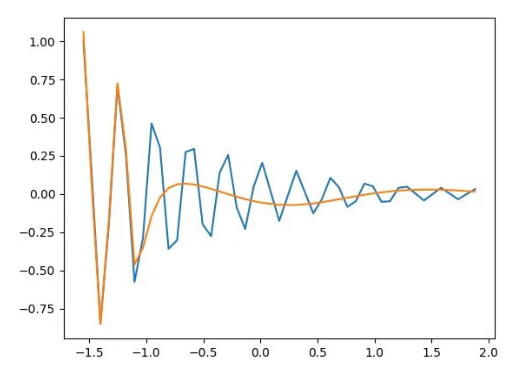

In [2]:
img = mpimg.imread(early_fit_graph_path)
plt.imshow(img)
plt.axis('off')
plt.show()

I also tried weighting the loss function by a normalized factor $\omega$ that depends on the magnitude of the data sample's position:
$$\omega = \lvert x \rvert^\alpha + \epsilon$$

The hyperparameter $\alpha$ determined how aggressive this weighting was: higher values put an even stronger emphasis on data samples with greater position magnitudes. $\epsilon$ is a small hyperparameter that sets the "weight floor", ensuring that data points with a small position magnitude are not ignored by the model entirely.

While this did result in improvements, a technique that used a similar strategy with significantly better results was using an exponential envelope to more directly force the model to predict lower amplitudes at later times rather than encouraging the model to focus more on earlier timestamps. Specifically, instead of adjusting the loss function, predictions were multiplied by this factor:
$$e^{-0.05t_{\text{raw}}}$$

Additionally, using this exponential envelope helped the model predict on the extrapolation task; it previously did not know anything about times outside of the training dataset, but the envelope, at later times, flattens predictions.

Potentially the most important adjustment made to the model was the addition of Fourier features, which excel in situations involving spectral bias. These are related to the Fourier series; similarly to them, Fourier features combine sinusoid curves and train the model by making these combinations as accurate as possible.

Given the time t, the following input features are fed into the model's input layer:

$$cos(\mathbf{b}_{1}t)+sin(\mathbf{b}_{1}t)+...+cos(\mathbf{b}_{n}t)+sin(\mathbf{b}_{n}t)$$

Where $n$ is the number of Fourier features chosen, and $\mathbf{b}$ is a vector of $n$ random constants chosen (in this case from a uniform distribution) when the Fourier feature object is instantiated.

The input variable t is multiplied by a constant in each term, then the sine or cosine function is applied to the resulting product.

# Model

The model architecture is a neural network that prioritized width over depth, since this problem can be modeled by a simple, predictable equation.

I used tanh activation to make double derivatives (from acceleration = $\ddot{x}$) nonzero, which is commonly used in PINNs:
$$\text{ReLU}(x) = max(0, x) \in \{0, x\}$$
$$\frac{d}{dx}\text{ReLU}(x) = \frac{d}{dx}max(0, x) \in \{0, 1\}$$
$$\frac{d^2}{dx^2}\text{ReLU}(x) = \frac{d^2}{dx^2}max(0, x) = \frac{d}{dx}max(0, 1) = 0$$

Just with the neural network and tanh activations, this was the result. The network collapsed to the near-zero solution, the local minima.

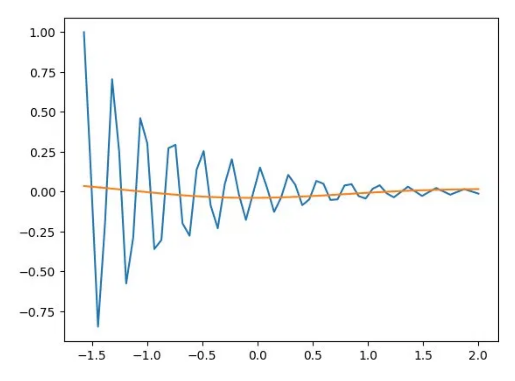

In [3]:
img = mpimg.imread(collapsing_graph_file_path)
plt.imshow(img)
plt.axis('off')
plt.show()

This is the graph of extrapolation testing before using the exponential envelope. The later times are unknown to the model and thus are predicted very inaccurately.

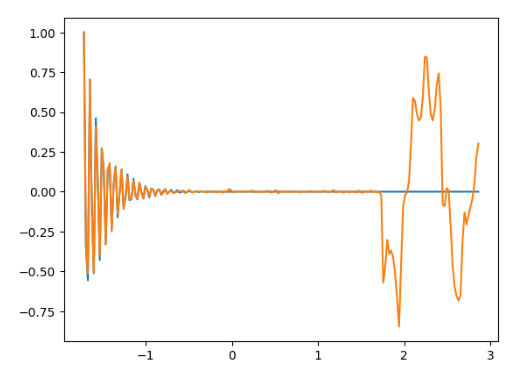

In [4]:
img = mpimg.imread(extrapolation_failure_path)
plt.imshow(img)
plt.axis('off')
plt.show()

The final model performed significantly better overall:

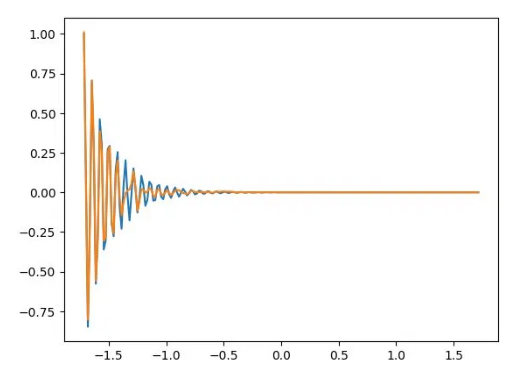

In [5]:
img = mpimg.imread(prediction_graph_path)
plt.imshow(img)
plt.axis('off')
plt.show()

Model training and convergence took a long time, hundreds of epochs, which is common for PINNs and can be seen from the loss graphs:

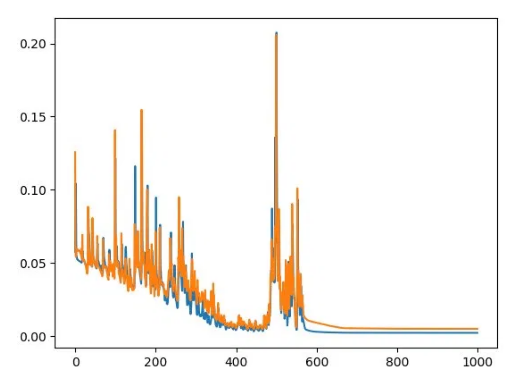

In [6]:
img = mpimg.imread(loss_curve_graph_path)
plt.imshow(img)
plt.axis('off')
plt.show()

# Loss

Using the 2nd order ordinary differential equation for damped harmonic motion:
$$m\frac{d^2x}{dt^2} + c\frac{dx}{dt} + kx = 0$$
$$m\ddot{x} + c\dot{x} + kx = 0$$
$$(1.0kg) \cdot \ddot{x} + (0.1\frac{Ns}{m}) \cdot \dot{x} + (1.0\frac{N}{m}) \cdot x = 0$$

In a PINN, loss functions account for both data loss (deviation from the data points) and physics loss (deviation from known physics equations such as the one above). The physics loss in this situation comes from the root mean squared error (RMSE) of this left hand side from 0.

Combining these two loss values to get a singular loss, I use a tuned constant $\lambda$ weighting the physics loss, making the (unweighted) loss function:

$$L(x, \dot{x}, \ddot{x}, \hat{x}, \dot{\hat{x}}, \ddot{\hat{x}}) = L_{\text{data}} + \lambda \cdot L_{\text{physics}}$$
$$L(x, \dot{x}, \ddot{x}, \hat{x}, \dot{\hat{x}}, \ddot{\hat{x}}) = (\ddot{x}-\ddot{\hat{x}})^2 + (\dot{x}-\dot{\hat{x}})^2 + (x-\hat{x})^2 + \lambda \cdot (\ddot{\hat{x}} + 0.1\dot{\hat{x}} + \hat{x})^2$$

for one prediction, where the dots over the x's represent derivatives with respect to time and the hats represent the predicted values rather than ground truth ones.

This function can be combined with the weighting factor to get the final loss function:

$$L_{\text{weighted}}(x, \dot{x}, \ddot{x}, \hat{x}, \dot{\hat{x}}, \ddot{\hat{x}}) = (\lvert x \rvert^\alpha + \epsilon)[(\ddot{x}-\ddot{\hat{x}})^2 + (\dot{x}-\dot{\hat{x}})^2 + (x-\hat{x})^2 + \lambda \cdot (\ddot{\hat{x}} + 0.1\dot{\hat{x}} + \hat{x})^2]$$

# Importing Data

This dataset class stores the data internally and becomes an object to be used later on.

In [7]:
class DampedOscillatorDataset(Dataset):
  def __init__(self, file_path):
    self.DataFrame = pd.read_csv(file_path) # initially read as pandas DF
    self.raw_data = self.DataFrame.to_numpy() # convert to numpy, eliminates col names
    print("Data type:", self.raw_data.dtype)
    self.X, self.y = self.raw_data[:, 0], self.raw_data[:, 1:] # split into input/output
    self.X = np.expand_dims(self.X, axis=1) # make each sample a 1d array of size 1
    print("X shape:", self.X.shape)
    print("Y shape:", self.y.shape)

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

Loading the data and seeing first few entries:

In [8]:
dataset = DampedOscillatorDataset(train_data_file_path)
print("First 5 rows of input: \n", dataset.X[:5])
print("First 5 rows of output: \n", dataset.y[:5])

Data type: float64
X shape: (200, 1)
Y shape: (200, 3)
First 5 rows of input: 
 [[0.       ]
 [1.5075377]
 [3.0150754]
 [4.522613 ]
 [6.030151 ]]
First 5 rows of output: 
 [[ 1.          0.         -1.        ]
 [ 0.10670093 -0.92658556 -0.01404238]
 [-0.84717494 -0.11187882  0.85836285]
 [-0.19405991  0.78341     0.11571891]
 [ 0.7051903   0.19081393 -0.7242717 ]]


# EDA

Seeing the rough shape of the graphs of each of x, v, and a:

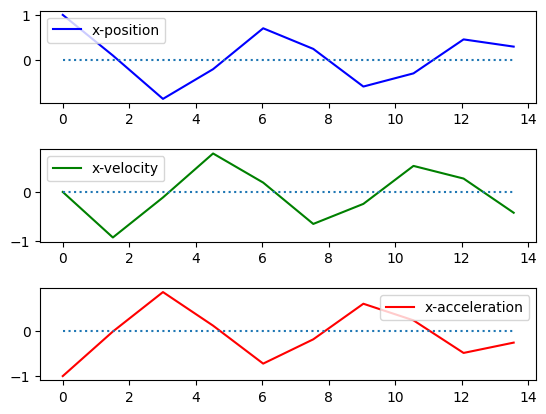

In [9]:
t = np.squeeze(dataset.X) # make input 1d array again
x = dataset.y[:, 0]
v = dataset.y[:, 1]
a = dataset.y[:, 2]

graph_samples = 10

fig, ax = plt.subplots(3)
plt.subplots_adjust(hspace=0.5)

ax[0].plot(t[:graph_samples], x[:graph_samples], color='blue', label='x-position')
ax[0].plot(t[:graph_samples], [0] * graph_samples, linestyle='dotted')
ax[0].legend()

ax[1].plot(t[:graph_samples], v[:graph_samples], color='green', label='x-velocity')
ax[1].plot(t[:graph_samples], [0] * graph_samples, linestyle='dotted')
ax[1].legend()

ax[2].plot(t[:graph_samples], a[:graph_samples], color='red', label='x-acceleration')
ax[2].plot(t[:graph_samples], [0] * graph_samples, linestyle='dotted')
ax[2].legend()

plt.show()

Finding the range of each column of the training dataset

In [10]:
print("t range:", dataset.X.min(), dataset.X.max())
print("x range:", dataset.y[:, 0].min(), dataset.y[:, 0].max())
print("v range:", dataset.y[:, 1].min(), dataset.y[:, 1].max())
print("a range:", dataset.y[:, 2].min(), dataset.y[:, 2].max())

t range: 0.0 300.0
x range: -0.84717494 1.0
v range: -0.92658556 0.78341
a range: -1.0 0.85836285


In [11]:
a_mean = np.mean(a)
v_mean = np.mean(v)
x_mean = np.mean(x)

# Training

Dividing the dataset into training and validation:

In [12]:
# interleaved splitting to preserve temporal order

train_idx = []
val_idx = []

for i in range(len(dataset)):
  if i % 3 == 2:
    val_idx.append(i)

  else:
    train_idx.append(i)

train_data = torch.utils.data.Subset(dataset, train_idx)
val_data = torch.utils.data.Subset(dataset, val_idx)
print(train_idx)

[0, 1, 3, 4, 6, 7, 9, 10, 12, 13, 15, 16, 18, 19, 21, 22, 24, 25, 27, 28, 30, 31, 33, 34, 36, 37, 39, 40, 42, 43, 45, 46, 48, 49, 51, 52, 54, 55, 57, 58, 60, 61, 63, 64, 66, 67, 69, 70, 72, 73, 75, 76, 78, 79, 81, 82, 84, 85, 87, 88, 90, 91, 93, 94, 96, 97, 99, 100, 102, 103, 105, 106, 108, 109, 111, 112, 114, 115, 117, 118, 120, 121, 123, 124, 126, 127, 129, 130, 132, 133, 135, 136, 138, 139, 141, 142, 144, 145, 147, 148, 150, 151, 153, 154, 156, 157, 159, 160, 162, 163, 165, 166, 168, 169, 171, 172, 174, 175, 177, 178, 180, 181, 183, 184, 186, 187, 189, 190, 192, 193, 195, 196, 198, 199]


Normalizing the time:

In [13]:
# normalizing data
t_mean = dataset.X[train_data.indices].mean()
t_std = dataset.X[train_data.indices].std()

dataset.X = (dataset.X - t_mean) / t_std

print(dataset.X)

t_mean_tensor = torch.tensor(t_mean, dtype=torch.float64)
t_std_tensor = torch.tensor(t_std, dtype=torch.float64)

[[-1.71494385]
 [-1.69770823]
 [-1.68047261]
 [-1.663237  ]
 [-1.64600138]
 [-1.62876576]
 [-1.61153015]
 [-1.59429453]
 [-1.57705891]
 [-1.55982329]
 [-1.54258768]
 [-1.52535207]
 [-1.50811645]
 [-1.49088083]
 [-1.47364521]
 [-1.45640959]
 [-1.43917397]
 [-1.42193836]
 [-1.40470273]
 [-1.38746712]
 [-1.3702315 ]
 [-1.35299588]
 [-1.33576027]
 [-1.31852466]
 [-1.30128905]
 [-1.28405343]
 [-1.26681781]
 [-1.24958219]
 [-1.23234657]
 [-1.21511095]
 [-1.19787536]
 [-1.18063971]
 [-1.1634041 ]
 [-1.14616848]
 [-1.12893286]
 [-1.11169725]
 [-1.09446161]
 [-1.07722601]
 [-1.05999039]
 [-1.04275477]
 [-1.02551915]
 [-1.00828353]
 [-0.99104791]
 [-0.97381234]
 [-0.9565767 ]
 [-0.93934111]
 [-0.92210552]
 [-0.90486988]
 [-0.88763424]
 [-0.8703986 ]
 [-0.85316302]
 [-0.83592742]
 [-0.81869178]
 [-0.80145614]
 [-0.78422054]
 [-0.76698497]
 [-0.74974932]
 [-0.73251368]
 [-0.71527804]
 [-0.69804245]
 [-0.68080686]
 [-0.66357122]
 [-0.64633558]
 [-0.62909994]
 [-0.61186436]
 [-0.59462876]
 [-0.57739

Creating the DataLoader objects that load batches efficiently in PyTorch:

In [14]:
train_dataloader = DataLoader(train_data, batch_size=16, num_workers=2)
val_dataloader = DataLoader(val_data, batch_size=16, num_workers=2)

Checking batch sizes:

In [15]:
for x, y in train_dataloader: # test one batch for shape
  print("X: ", x.shape)
  print("Y: ", y.shape)
  break

X:  torch.Size([16, 1])
Y:  torch.Size([16, 3])


These are the fourier features and model classes, containing the architecture and creating the features from the input data.

In [16]:
class FourierFeatures(nn.Module):
    def __init__(self, n_features=32, scale=10.0):
        super().__init__()
        B = torch.randn(1, n_features, dtype=torch.float64) * scale
        self.register_buffer('B', B) # fixes the frequencies while saving them

    def forward(self, t):
        proj = t @ self.B  # (batch, n_features)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (batch, 2*n_features)

class DampedOscillatorModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.fourier = FourierFeatures(n_features=32)
    self.layers = nn.Sequential(
      # takes in time as a vector of 64 (because of fourier features)
      nn.Linear(64, 128),
      nn.Tanh(),
      nn.Linear(128, 128),
      nn.Tanh(),
      nn.Linear(128, 128),
      nn.Tanh(),
      nn.Linear(128, 1)
    )

  def forward(self, t):
    t_encoded = self.fourier(t)
    return self.layers(t_encoded)

  def predict(self, times):
    # getting all outputs from x
    times = times.requires_grad_(True)

    t_real = times * t_std_tensor + t_mean_tensor
    envelope = torch.exp(-0.05 * t_real)

    x = self.forward(times) * envelope# call the forward() function
    v = torch.autograd.grad(x.sum(), times, create_graph=True)[0]
    a = torch.autograd.grad(v.sum(), times, create_graph=True)[0]
    return x, v, a

Creating the model object and converting its parameters to doubles, which are more precise and match the data type of the data.

In [17]:
model = DampedOscillatorModel()
model.double() # convert parameters to double (float64)

DampedOscillatorModel(
  (fourier): FourierFeatures()
  (layers): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

Loss function and optimizer: very patient scheduler since this model takes a long time to converge.

In [18]:
# criterion = nn.MSELoss() # default, reduction is 'mean'
optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=100)
# ^  LR scheduler to prevent overshooting

Loss function - an addition made to the loss function described at the top of the notebook is weighted loss, prioritizing earlier instances of time because they have more important signal: damping has a huge effect at later times and makes kinematic values essentially zero.

In [19]:
def loss(labels, x, v, a, lamb_phys):
  # x, v, a, and all label columns are taken as 2d tensors, not 1d
  x_gt = labels[:, 0].unsqueeze(1)
  v_gt = labels[:, 1].unsqueeze(1)
  a_gt = labels[:, 2].unsqueeze(1)

  weights = (x_gt.abs()) ** 2 + 0.03
  weights = weights / weights.mean()

  mse_loss = torch.mean(((x_gt - x) ** 2 + (v_gt - v) ** 2 + (a_gt - a) ** 2)) # REMOVING WEIGHTS!
  physics_loss = torch.mean( (1.0*a + 0.1*v + 1.0*x)**2 ) # ma+bv+x = 0
  train_loss = (mse_loss + lamb_phys * physics_loss)
  return train_loss # returns 1-element tensor

Defining variables to be used in the training loop. Again, the number of epochs is very high and model patience is set to the same number to not have early stopping.

In [20]:
num_epochs = 1000
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_epoch = 0
model_patience = 1000

Training Loop

In [21]:
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  lamb_phys = 0.0 if epoch < 20 else 0.5

  for times, labels in tqdm(train_dataloader, desc='Training...'):
    optimizer.zero_grad() # reset the gradients after each batch

    x, v, a = model.predict(times=times)
    # use chain rule to get actual derivatives
    v_real = v / t_std_tensor
    a_real = a / (t_std_tensor ** 2)
    # loss
    current_loss = loss(labels=labels, x=x, v=v_real, a=a_real, lamb_phys=lamb_phys)

    current_loss.backward() # backpropagation


    # nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping after backprop
    optimizer.step()

    # get the average loss and multiply by count, add to running total
    running_loss += current_loss.item() * times.size(0)

  train_loss = running_loss / len(train_dataloader.dataset)
  train_losses.append(train_loss)





  # validating
  model.eval()
  running_loss = 0.0
  current_loss = None
  # with torch.no_grad(): ???
  for times, labels in tqdm(val_dataloader, desc='Validating...'):
    # make prediction
    with torch.enable_grad():
      x, v, a = model.predict(times=times)

    with torch.no_grad():
      # use chain rule to get actual derivatives
      v_real = v / t_std_tensor
      a_real = a / (t_std_tensor ** 2)

      current_loss = loss(labels, x, v_real, a_real, lamb_phys=lamb_phys)
      running_loss += current_loss.item() * times.size(0)


  val_loss = running_loss / len(val_dataloader.dataset)
  val_losses.append(val_loss)



  scheduler.step(val_loss) # change the learning rate BASED ON VAL LOSS


  # save epoch and update loss, check for patience
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    best_epoch = epoch

    torch.save(model.state_dict(), best_model_path)
    print(f"New best model saved at epoch {epoch+1}")
  elif epoch - best_epoch >= model_patience:
    print(f"Model has not improved in {model_patience} epochs - stopping now, best model was at epoch {best_epoch}")
    break


  print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")

Training...:   0%|          | 0/9 [00:00<?, ?it/s]

Validating...:   0%|          | 0/5 [00:00<?, ?it/s]

New best model saved at epoch 1
Epoch 1/1000 - Train loss: 0.05729919381246464, Validation loss: 0.12878524108542694


Training...:   0%|          | 0/9 [00:00<?, ?it/s]

Validating...:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training...:   0%|          | 0/9 [00:00<?, ?it/s]

Validating...:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 40/1000 - Train loss: 0.05707779530286164, Validation loss: 0.06366957926061972


Training...:   0%|          | 0/9 [00:00<?, ?it/s]

KeyboardInterrupt: 

Checking std, mean of weights and outputs to check for model collapsing (having most weights essentially zero)

In [22]:
for name, param in model.named_parameters():
    print(name, param.abs().mean().item())

model.eval()
t_all = torch.tensor(dataset.X, dtype=torch.float64)
x_pred, _, _ = model.predict(t_all)
print("predicted std:", torch.std(x_pred).item())
print("predicted range:", x_pred.min().item(), "to", x_pred.max().item())

layers.0.weight 0.05961042858403942
layers.0.bias 0.06361622958904731
layers.2.weight 0.03948750185904126
layers.2.bias 0.036241740283144946
layers.4.weight 0.03780455801110428
layers.4.bias 0.05197481654228561
layers.6.weight 0.020910453069620888
layers.6.bias 0.037463553404370714
predicted std: 0.02685822510433917
predicted range: -0.05341758873982679 to 0.33296430023828183


# Visualizing Results

Checking loss values over time:

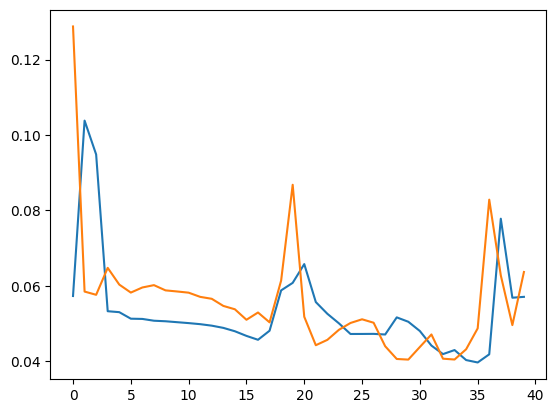

In [23]:
epochs_ran = min(len(train_losses), len(val_losses))
plt.plot([i for i in range(epochs_ran)], train_losses[:epochs_ran])
plt.plot([i for i in range(epochs_ran)], val_losses[:epochs_ran])
plt.show()

Graphing the predictions on the training/validation set with the ground truth labels to check how well the model fits:

tensor(0.0269, dtype=torch.float64, grad_fn=<StdBackward0>)


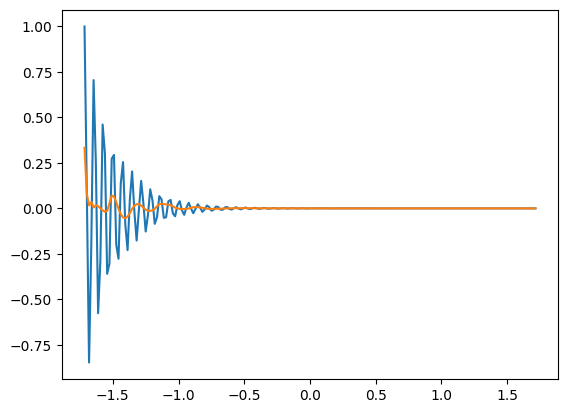

[ 1.00000000e+00  1.06700934e-01 -8.47174940e-01 -1.94059910e-01
  7.05190300e-01  2.52049770e-01 -5.76070600e-01 -2.86334800e-01
  4.60883440e-01  3.01914450e-01 -3.59932870e-01 -3.03123150e-01
  2.72963760e-01  2.93662130e-01 -1.99307370e-01 -2.76632070e-01
  1.38014700e-01  2.54584300e-01 -8.79616140e-02 -2.29578400e-01
  4.79322500e-02  2.03238790e-01 -1.66846230e-02 -1.76811870e-01
 -6.99899900e-03  1.51223570e-01  2.42787260e-02 -1.27129720e-01
 -3.62311600e-02  1.04964410e-01  4.38346700e-02 -8.49830600e-02
 -4.79615030e-02  6.72993960e-02  4.93756940e-02 -5.19196880e-02
 -4.87349480e-02  3.87696600e-02  4.65960650e-02 -2.77180190e-02
 -4.34221100e-02  1.85962170e-02  3.95910330e-02 -1.12133730e-02
 -3.54046040e-02  5.36930370e-03  3.10983660e-02 -8.63012300e-04
 -2.68506430e-02 -2.49978100e-03  2.27912850e-02  4.90184900e-03
 -1.90100100e-02 -6.51120670e-03  1.55635630e-02  7.47922670e-03
 -1.24825270e-02 -7.93974800e-03  9.77703900e-03  8.00917800e-03
 -7.44178100e-03 -7.78689

In [24]:
x_pred, _, _ = model.predict(torch.tensor(dataset.X))

plt.plot(dataset.X, dataset.y[:, 0])
plt.plot(dataset.X, x_pred.detach().numpy())
print(torch.std(x_pred))
plt.show()

print(dataset.y[:, 0])

# Testing Model

Creating data objects for each of the three testing datasets:

In [25]:
completion_dataset = DampedOscillatorDataset(completion_file_path)
reconstruction_dataset = DampedOscillatorDataset(reconstruction_file_path)
extrapolation_dataset = DampedOscillatorDataset(extrapolation_file_path)

completion_dataloader = DataLoader(completion_dataset, batch_size=16, num_workers=2)
reconstruction_dataloader = DataLoader(reconstruction_dataset, batch_size=16, num_workers=2)
extrapolation_dataloader = DataLoader(extrapolation_dataset, batch_size=16, num_workers=2)

Data type: float64
X shape: (300, 1)
Y shape: (300, 3)
Data type: float64
X shape: (200, 1)
Y shape: (200, 3)
Data type: float64
X shape: (200, 1)
Y shape: (200, 3)


Normalize using the same training normalizer - using different normalizing values would throw the model off completely

In [26]:
# normalizing data
completion_dataset.X = (completion_dataset.X - t_mean) / t_std
reconstruction_dataset.X = (reconstruction_dataset.X - t_mean) / t_std
extrapolation_dataset.X = (extrapolation_dataset.X - t_mean) / t_std

Loading the model with the lowest validation loss obtained during training

In [27]:
best_model = DampedOscillatorModel()
best_model.load_state_dict(torch.load(best_model_path))
best_model.double()

DampedOscillatorModel(
  (fourier): FourierFeatures()
  (layers): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

Running the best model through the three testing datasets and tracking losses:

In [28]:
test_losses = [0, 0, 0]

running_loss = 0.0
# ok to not call torch.no_grad() but make sure backward() is not being called
best_model.eval()
for times, labels in tqdm(completion_dataloader, desc='Testing...'):
  x, v, a = best_model.predict(times)

  # using chain rule to differentiate correctly
  v_real = v / t_std_tensor
  a_real = a / (t_std_tensor ** 2)

  current_loss = loss(labels, x, v_real, a_real, 0.5)
  running_loss += current_loss.item() * times.size(0)
test_losses[0] = running_loss / len(completion_dataset)


running_loss = 0.0
# ok to not call torch.no_grad() but make sure backward() is not being called
best_model.eval()
for times, labels in tqdm(reconstruction_dataloader, desc='Testing...'):
  x, v, a = best_model.predict(times)

  # using chain rule to differentiate correctly
  v_real = v / t_std_tensor
  a_real = a / (t_std_tensor ** 2)

  current_loss = loss(labels, x, v_real, a_real, 0.5)
  running_loss += current_loss.item() * times.size(0)
test_losses[1] = running_loss / len(reconstruction_dataset)


running_loss = 0.0
# ok to not call torch.no_grad() but make sure backward() is not being called
best_model.eval()
for times, labels in tqdm(extrapolation_dataloader, desc='Testing...'):
  x, v, a = best_model.predict(times)

  # using chain rule to differentiate correctly
  v_real = v / t_std_tensor
  a_real = a / (t_std_tensor ** 2)

  current_loss = loss(labels, x, v_real, a_real, 0.5)
  running_loss += current_loss.item() * times.size(0)
test_losses[2] = running_loss / len(extrapolation_dataset)




print("Completion test loss:", test_losses[0])
print("Reconstruction test loss:", test_losses[1])
print("Extrapolation test loss:", test_losses[2])

Testing...:   0%|          | 0/19 [00:00<?, ?it/s]

Testing...:   0%|          | 0/13 [00:00<?, ?it/s]

Testing...:   0%|          | 0/13 [00:00<?, ?it/s]

Completion test loss: 0.04486280149759934
Reconstruction test loss: 0.04551118575116683
Extrapolation test loss: 0.036714771923650115


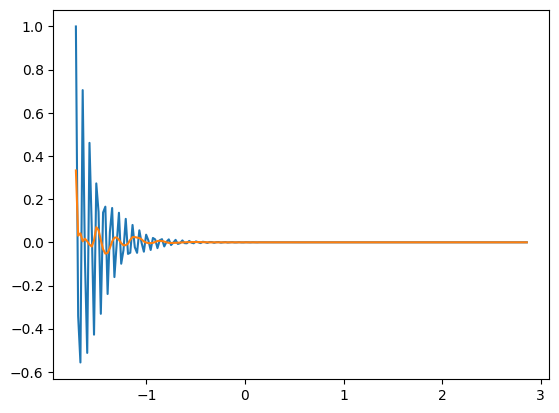

In [29]:
extrapolation_pred, _, _ = model.predict(torch.tensor(extrapolation_dataset.X))

plt.plot(extrapolation_dataset.X, extrapolation_dataset.y[:, 0])
plt.plot(extrapolation_dataset.X, extrapolation_pred.detach().numpy())
plt.show()